In [18]:
import cv2

In [9]:
img = cv2.imread("../backend/uploads/2_20260901_114454_3730a1d0.png")

In [10]:
if img is None:
    raise ValueError("Unable load image")

In [11]:
img.shape

(1024, 1024, 3)

In [12]:
resized = cv2.resize(img, (224,224))
resized.shape

(224, 224, 3)

In [13]:
normalized = resized/255.0

In [14]:
print(resized.min())
print(resized.max())
print(normalized.min())
print(normalized.max())

7
255
0.027450980392156862
1.0


In [15]:
image = cv2.imread("../mvtec_anomaly_detection/cable/train/good/000.png")

In [16]:
rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

In [18]:
resized_image = cv2.resize(rgb_image, (224, 224))

In [19]:
normalized_image = resized_image/255.0

In [20]:
print("Oroginal image shape:", image.shape)
print("RGB image shape:", rgb_image.shape)
print("Resized image shape:", resized_image.shape)
print("Normalized image shape:",normalized_image.shape)
print("Data type:",normalized_image.dtype)
print("Min value after normalization:",normalized_image.min())
print("Max value after normalization:",normalized_image.max())

Oroginal image shape: (1024, 1024, 3)
RGB image shape: (1024, 1024, 3)
Resized image shape: (224, 224, 3)
Normalized image shape: (224, 224, 3)
Data type: float64
Min value after normalization: 0.027450980392156862
Max value after normalization: 1.0


In [6]:
import matplotlib.pyplot as plt

plt.imshow(image)
plt.title("Original Open CV image")
plt.axis("off")

NameError: name 'image' is not defined

(np.float64(-0.5), np.float64(1023.5), np.float64(1023.5), np.float64(-0.5))

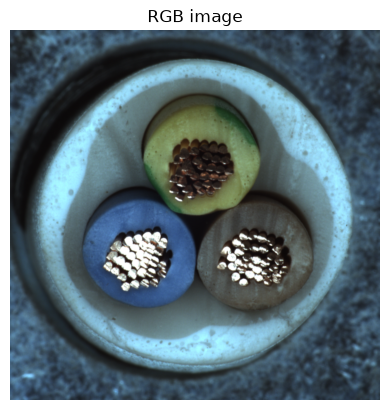

In [25]:
plt.imshow(rgb_image)
plt.title("RGB image")
plt.axis("off")

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

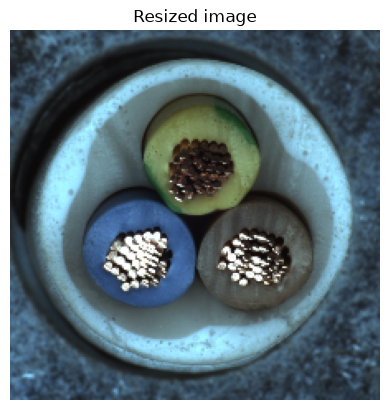

In [26]:
plt.imshow(resized_image)
plt.title("Resized image")
plt.axis("off")

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

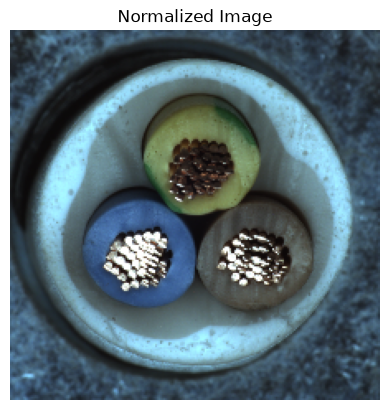

In [27]:
plt.imshow(normalized_image)
plt.title("Normalized Image")
plt.axis("off")

In [44]:
img = cv2.imread("../mvtec_anomaly_detection/capsule/test/faulty_imprint/001.png")

In [45]:
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
resize = cv2.resize(img_rgb, (224, 224))
normal = resize/255.0

(np.float64(-0.5), np.float64(999.5), np.float64(999.5), np.float64(-0.5))

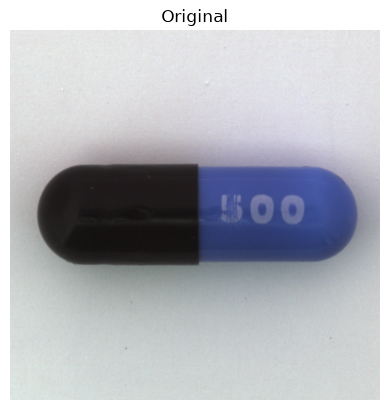

In [46]:
plt.imshow(img)
plt.title("Original")
plt.axis("off")

(np.float64(-0.5), np.float64(999.5), np.float64(999.5), np.float64(-0.5))

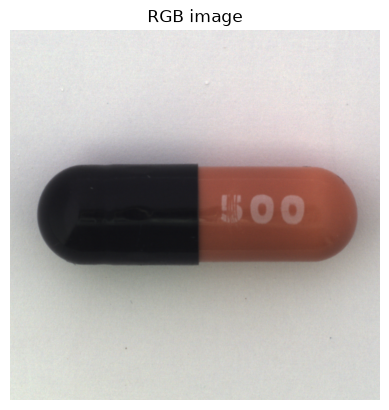

In [47]:
plt.imshow(img_rgb)
plt.title("RGB image")
plt.axis("off")

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

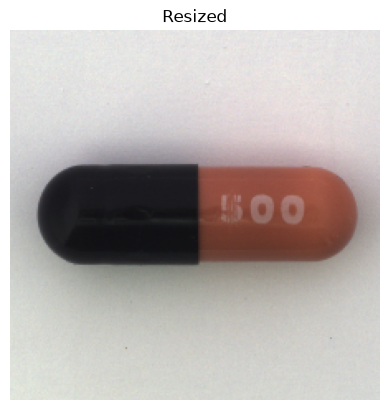

In [48]:
plt.imshow(resize)
plt.title("Resized")
plt.axis("off")

In [7]:
image = cv2.imread("../mvtec_anomaly_detection/capsule/test/scratch/002.png")
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
brightness = gray.mean()
brightness

np.float64(171.56032)

In [82]:
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
height, width = image_rgb.shape[:2]
height,width

(1024, 1024)

In [83]:
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
blur_score = cv2.Laplacian(gray, cv2.CV_64F).var()
blur_score

np.float64(14.43250830512261)

In [94]:
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
smooth = cv2.GaussianBlur(gray, (5, 5), 0)
import numpy as np
noise = gray.astype(np.float32) - smooth.astype(np.float32)
noise_score = noise.std()
print(noise_score)

1.1301845


| id | catagory | resolution | brightness | sharp | Noise |
|----|------|------|------|----| --- |
|1 | cable/good | (1024, 1024) | np.float64(104.21017360687256) | np.float64(38.56210868334165) | 2.3223126 |
| 2 | carpet/good | (1024, 1024) | np.float64(90.40099143981934) | np.float64(195.34405260336553) | 5.275918 |
| 3 | metal_nut/good | (700, 700) | np.float64(52.42697551020408) | np.float64(25.685265293061224) | 1.8560302 |
| 4 | grid/broken | (1024, 1024) | np.float64(123.78725528717041) | np.float64(24.365139785963947) | 1.9029955 |
| 5 | capsule/scrath | (1000, 1000) | np.float64(171.56032) | np.float64(13.103422807278998) | 1.1301845 |
| 6 | hazelnut/crack | (1024, 1024) | np.float64(47.86512470245361) | np.float64(14.43250830512261) | 1.1250615 |

In [4]:
import torch

In [9]:
print(image.shape)
print(image.dtype)

(1000, 1000, 3)
uint8


In [10]:
rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
print(rgb.shape)
print(rgb.dtype)

(1000, 1000, 3)
uint8


In [11]:
resized = cv2.resize(rgb,(224,224))
print(resized.shape)
print(resized.dtype)

(224, 224, 3)
uint8


In [12]:
tensor = torch.from_numpy(resized)
print(tensor.shape)
print(tensor.dtype)

torch.Size([224, 224, 3])
torch.uint8


In [13]:
tensor = tensor.permute(2,0,1)
print(tensor.shape)
print(tensor.dtype)

torch.Size([3, 224, 224])
torch.uint8


In [14]:
tensor = tensor.float()
print(tensor.shape)
print(tensor.dtype)

torch.Size([3, 224, 224])
torch.float32


In [15]:
tensor = tensor/255.0
print(tensor.shape)
print(tensor.dtype)

torch.Size([3, 224, 224])
torch.float32


In [16]:
print(tensor.shape)
print(tensor.dtype)
print(tensor.min())
print(tensor.max())

torch.Size([3, 224, 224])
torch.float32
tensor(0.0588)
tensor(0.9686)


## PyTorch Dataset

In [5]:
from torch.utils.data import Dataset

In [6]:
class MVTecDataset(Dataset):
    def __init__(self, image_paths) -> None:
        self.image_paths = image_paths
    def __len__(self) -> int:
        return len(self.image_paths)
    def __getitem__(self, index):
        image_path = self.image_paths[index]
        image= cv2.imread(image_path)
        rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        resized = cv2.resize(rgb, (224,224))
        tensor = torch.from_numpy(resized).permute(2,0,1).float()
        tensor = tensor/255.0
        return tensor, image_path


In [7]:
from pathlib import Path
import sys
PROJECT_ROOT = Path().cwd().parent
sys.path.append(str(PROJECT_ROOT))

In [8]:
from ai.dataset.mvtec_loader import MVTecLoader

In [9]:
dataset_loader = MVTecLoader(PROJECT_ROOT / "mvtec_anomaly_detection")

In [10]:
categories = dataset_loader.get_categories()

In [11]:
images_paths = []
for category in categories:
    for image in dataset_loader.load_category(category):
        if image['split']=="train" and image["defect_type"] == "good":
            images_paths.append(image["image_path"])
images_paths[2]

'/Users/vinaykumarmandalapu/Desktop/VisionInspect_AI/mvtec_anomaly_detection/bottle/train/good/002.png'

In [12]:
print(len(images_paths))
print(type(images_paths))

3629
<class 'list'>


In [13]:
dataset = MVTecDataset(image_paths=images_paths)
print(type(dataset))
print(type(dataset.image_paths))

<class '__main__.MVTecDataset'>
<class 'list'>


In [14]:
print(len(dataset))

3629


In [51]:
sample = dataset[0]
print(sample[0].shape)
print(sample[0].dtype)
print(sample[0].min())
print(sample[0].max())
print(sample[1])

torch.Size([3, 224, 224])
torch.float32
tensor(0.1137)
tensor(1.)
/Users/vinaykumarmandalapu/Desktop/VisionInspect_AI/mvtec_anomaly_detection/bottle/train/good/000.png


In [15]:
from torch.utils.data import DataLoader

In [16]:
datasets = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True
)
datasets

In [20]:
for images, paths in datasets:
    print(images.shape)
    break

torch.Size([32, 3, 224, 224])


In [21]:
import torch
from torchvision import models

In [22]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

In [23]:
model.fc = torch.nn.Identity()

In [24]:
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [25]:
tensor, image_path = dataset[0]
print(tensor.shape)
tensor = tensor.unsqueeze(0)
print(tensor.shape)

torch.Size([3, 224, 224])
torch.Size([1, 3, 224, 224])


In [61]:
model.eval()
with torch.no_grad():
    features = model(tensor)
features.shape

torch.Size([1, 512])

In [62]:
images, paths = next(iter(datasets))
images.shape

torch.Size([32, 3, 224, 224])

In [63]:
model.eval()
with torch.no_grad():
    features = model(images)
features.shape

torch.Size([32, 512])

In [64]:
feature_1 = features[0]
feature_2 = features[1]
dist = torch.linalg.vector_norm(feature_1-feature_2)
dist

tensor(23.3893)

In [65]:
print(paths[0])
print(paths[1])

/Users/vinaykumarmandalapu/Desktop/VisionInspect_AI/mvtec_anomaly_detection/hazelnut/train/good/126.png
/Users/vinaykumarmandalapu/Desktop/VisionInspect_AI/mvtec_anomaly_detection/carpet/train/good/149.png


In [27]:
hazelnut_paths = [
    path for path in images_paths
    if "/hazelnut/" in path
]

In [69]:
len(hazelnut_paths)

6

In [28]:
hazelnut_dataset = MVTecDataset(hazelnut_paths)

In [75]:
image1, path1 = hazelnut_dataset[0]
image2, path2 = hazelnut_dataset[1]
image1 = image1.unsqueeze(0)
image2 = image2.unsqueeze(0)
model.eval()
with torch.no_grad():
    feature1 = model(image1)
    feature2 = model(image2)

distance = torch.linalg.vector_norm(feature1 - feature2)
print(path1)
print(path2)
print(distance)

/Users/vinaykumarmandalapu/Desktop/VisionInspect_AI/mvtec_anomaly_detection/hazelnut/train/good/126.png
/Users/vinaykumarmandalapu/Desktop/VisionInspect_AI/mvtec_anomaly_detection/hazelnut/train/good/190.png
tensor(10.8188)


In [42]:
sample_paths = hazelnut_paths[:20]

In [43]:
sample_dataset = MVTecDataset(sample_paths)

In [44]:
sample_images = []

for i in range(len(sample_dataset)):
    image, _ = sample_dataset[i]
    sample_images.append(image)

sample_images = torch.stack(sample_images)

print(sample_images.shape)

torch.Size([20, 3, 224, 224])


In [45]:
model.eval()

with torch.no_grad():
    sample_features = model(sample_images)

print(sample_features.shape)

torch.Size([20, 512])


In [81]:
reference = sample_features[0]

In [88]:
distances = torch.linalg.vector_norm(
    sample_features - reference,
    dim=1
)

print(distances)

tensor([ 0.0000, 11.0903,  9.4945, 10.5679, 10.5386, 11.4665, 10.9315, 11.5725,
         9.8217, 10.5393, 10.7835, 11.5762, 10.2070, 11.1552,  8.1116, 11.6111,
         9.9399, 11.1843, 11.8066, 11.7933])


In [29]:
test = cv2.imread("/Users/vinaykumarmandalapu/Desktop/VisionInspect_AI/mvtec_anomaly_detection/hazelnut/test/hole/009.png")
test = cv2.cvtColor(test, cv2.COLOR_BGR2RGB)
test = cv2.resize(test, (224,224))
tensor = torch.from_numpy(test).permute(2,0,1).float()
tensor = tensor/255.0
tensor = tensor.unsqueeze(0)

In [91]:
model.eval()
with torch.no_grad():
    feature = model(tensor)
dist = torch.linalg.vector_norm(sample_features-feature, dim=1)
dist

tensor([12.6319, 13.9090, 13.6056, 15.7774, 14.5881, 14.0631, 14.4960, 16.5548,
        13.6241, 15.7408, 14.6090, 14.4088, 14.8074, 16.4448, 13.9728, 14.8935,
        15.2940, 16.0810, 16.3707, 16.5328])

In [92]:
print(model.layer4)

Sequential(
  (0): BasicBlock(
    (conv1): Conv2d(256, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (downsample): Sequential(
      (0): Conv2d(256, 512, kernel_size=(1, 1), stride=(2, 2), bias=False)
      (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
  )
  (1): BasicBlock(
    (conv1): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), b

In [30]:
feature_extractor = torch.nn.Sequential(
    model.conv1,
    model.bn1,
    model.relu,
    model.maxpool,
    model.layer1,
    model.layer2,
    model.layer3,
    model.layer4
)

In [ ]:
image, path = dataset[0]

image = image.unsqueeze(0)

feature_extractor.eval()

with torch.no_grad():
    feature_map = feature_extractor(image)

print(feature_map.shape)

torch.Size([1, 512, 7, 7])


In [107]:
print(image.shape)
tensor.shape

torch.Size([1, 3, 224, 224])


torch.Size([1, 3, 224, 224])

In [ ]:
local_features = feature_map.permute(0, 2, 3, 1)
print(local_features.shape)

torch.Size([1, 7, 7, 512])


In [ ]:
patch_features = local_features.reshape(1, 49, 512)
print(patch_features.shape)

torch.Size([1, 49, 512])


In [98]:
patch_features[0, 48]

tensor([0.1189, 0.0000, 0.0000, 0.8870, 0.0503, 0.0000, 0.0000, 0.8623, 0.3114,
        0.2145, 0.4897, 0.0748, 0.0000, 0.0000, 0.5179, 0.0000, 0.0000, 1.6000,
        0.0061, 0.0297, 0.6017, 0.0000, 0.0000, 0.0000, 0.2180, 0.0803, 0.0000,
        0.0000, 0.0000, 0.0399, 0.0000, 0.0000, 0.2397, 0.0000, 0.0000, 0.0000,
        0.7388, 0.0000, 0.9960, 0.2533, 0.1302, 0.0000, 0.0000, 0.9945, 0.0000,
        0.3003, 0.7460, 0.0000, 1.2591, 0.6741, 0.0000, 0.0000, 1.0405, 0.0000,
        4.3868, 0.0000, 0.0000, 0.3984, 0.0000, 0.2347, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.2370, 0.0000, 0.0000, 1.1169, 0.0000,
        0.2276, 1.4822, 0.0000, 0.0000, 0.0000, 0.1176, 0.0000, 0.0000, 2.0043,
        5.2619, 2.7702, 0.0000, 0.0000, 0.0000, 0.4311, 0.1515, 0.0000, 0.5355,
        0.0000, 0.0000, 0.0000, 0.0000, 1.7776, 1.5010, 0.7556, 0.0000, 0.0000,
        0.0000, 0.0000, 0.1331, 0.0000, 0.0000, 3.3234, 3.5755, 0.8364, 0.5767,
        0.4883, 0.0000, 0.0000, 0.0000, 

In [100]:
print(patch_features[0, 0].shape)
print(patch_features[0, 0][:10])

torch.Size([512])
tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0553, 0.2751,
        0.0000])


In [121]:
feature_extractor.eval()

with torch.no_grad():
    feature_map2 = feature_extractor(image2)

In [31]:
tensor.shape

torch.Size([1, 3, 224, 224])

In [32]:
normal_image1, _ = hazelnut_dataset[0]
normal_image2, _ = hazelnut_dataset[1]
normal_image1 = normal_image1.unsqueeze(0)
normal_image2 = normal_image2.unsqueeze(0)

In [33]:
feature_extractor.eval()
with torch.no_grad():
    feature1 = feature_extractor(normal_image1)
    feature2 = feature_extractor(normal_image2)
    feature_test3 = feature_extractor(tensor)

In [35]:
feature1 = feature1.permute(0,2,3,1)
feature2 = feature2.permute(0,2,3,1)
feature_test3 = feature_test3.permute(0,2,3,1)
feature_test3.shape

torch.Size([1, 7, 7, 512])

In [36]:
feature1 = feature1.reshape([1,49,512])
feature2 = feature2.reshape([1,49,512])
feature_test3 = feature_test3.reshape([1,49,512])
feature_test3.shape

torch.Size([1, 49, 512])

In [39]:
normal_defect_distances = torch.linalg.vector_norm(feature1-feature_test3, dim=2)
normal_normal_distances = torch.linalg.vector_norm(feature1-feature2, dim=2)

In [40]:
anomaly_map = normal_defect_distances.reshape(7, 7)
print(anomaly_map)
print(anomaly_map.shape)

tensor([[ 2.0199,  9.0891, 15.1074, 18.3498, 12.5329,  6.6099,  2.5267],
        [ 8.8502, 22.7989, 31.8483, 37.5729, 31.0720, 20.4845,  8.2111],
        [13.8345, 28.8927, 40.6103, 47.2519, 43.7160, 31.7671, 15.5651],
        [16.1083, 29.3225, 38.1791, 45.9027, 47.2207, 35.5638, 19.3637],
        [12.3361, 20.7520, 28.8246, 36.9422, 38.9258, 30.5018, 17.4028],
        [ 5.6579, 13.7086, 19.0481, 23.7887, 23.6294, 19.1602, 10.7868],
        [ 1.9648,  6.3249, 10.2711, 13.3809, 11.5614,  8.7562,  4.4060]])
torch.Size([7, 7])


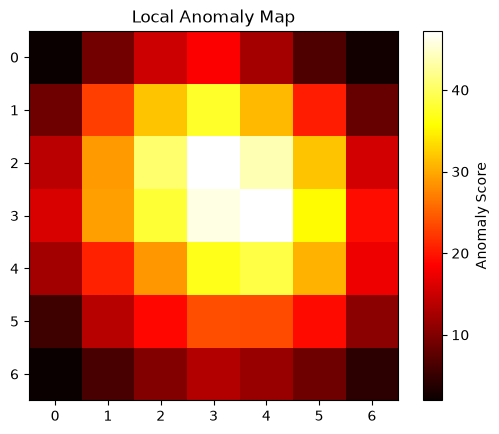

In [41]:
import matplotlib.pyplot as plt
plt.imshow(anomaly_map.numpy(), cmap="hot")
plt.colorbar(label="Anomaly Score")
plt.title("Local Anomaly Map")
plt.show()

In [46]:
normal_images = []

for i in range(len(sample_dataset)):
    image, _ = sample_dataset[i]
    normal_images.append(image)

normal_images = torch.stack(normal_images)

print(normal_images.shape)

torch.Size([20, 3, 224, 224])


In [47]:
feature_extractor.eval()

with torch.no_grad():
    normal_feature_maps = feature_extractor(normal_images)

print(normal_feature_maps.shape)

torch.Size([20, 512, 7, 7])


In [48]:
normal_local_features = normal_feature_maps.permute(0, 2, 3, 1)

normal_local_features = normal_local_features.reshape(20, 49, 512)

print(normal_local_features.shape)

torch.Size([20, 49, 512])


In [49]:
normal_reference = normal_local_features.mean(dim=0)

print(normal_reference.shape)

torch.Size([49, 512])


In [50]:
feature_test3.shape

torch.Size([1, 49, 512])

In [51]:
anomaly_scores = torch.linalg.vector_norm(
    feature_test3[0] - normal_reference,
    dim=1
)
print(anomaly_scores)
print(anomaly_scores.shape)

tensor([ 1.8389,  5.1670, 11.0306, 14.5776, 11.1871,  6.0773,  1.9879,  3.7877,
        13.2722, 24.8148, 34.2995, 29.8240, 18.5900,  6.6269,  6.6517, 17.9379,
        33.4310, 44.1257, 41.0624, 28.1517, 13.3602,  9.1990, 20.6122, 34.9317,
        46.0374, 45.8685, 32.1910, 16.3030,  8.1802, 17.0599, 27.9000, 35.9340,
        36.6879, 26.8460, 14.3682,  4.8492, 11.7168, 18.0956, 22.3262, 21.5194,
        16.3024,  8.7675,  1.4306,  5.1592,  9.3119, 12.0146,  9.9279,  6.3780,
         2.8817])
torch.Size([49])


In [52]:
anomaly_map = anomaly_scores.reshape(7, 7)

print(anomaly_map)

tensor([[ 1.8389,  5.1670, 11.0306, 14.5776, 11.1871,  6.0773,  1.9879],
        [ 3.7877, 13.2722, 24.8148, 34.2995, 29.8240, 18.5900,  6.6269],
        [ 6.6517, 17.9379, 33.4310, 44.1257, 41.0624, 28.1517, 13.3602],
        [ 9.1990, 20.6122, 34.9317, 46.0374, 45.8685, 32.1910, 16.3030],
        [ 8.1802, 17.0599, 27.9000, 35.9340, 36.6879, 26.8460, 14.3682],
        [ 4.8492, 11.7168, 18.0956, 22.3262, 21.5194, 16.3024,  8.7675],
        [ 1.4306,  5.1592,  9.3119, 12.0146,  9.9279,  6.3780,  2.8817]])


In [53]:
overall_score = anomaly_scores.max()

print(overall_score)

tensor(46.0374)


In [54]:
hazelnut_test_good = [
    item["image_path"]
    for item in dataset_loader.load_category("hazelnut")
    if item["split"] == "test" and item["defect_type"] == "good"
]

print(hazelnut_test_good[0])

/Users/vinaykumarmandalapu/Desktop/VisionInspect_AI/mvtec_anomaly_detection/hazelnut/test/good/002.png


In [55]:
normal_test_dataset = MVTecDataset(hazelnut_test_good[:1])

normal_test_image, normal_test_path = normal_test_dataset[0]

normal_test_image = normal_test_image.unsqueeze(0)

with torch.no_grad():
    normal_test_feature_map = feature_extractor(normal_test_image)

normal_test_local_features = normal_test_feature_map.permute(0, 2, 3, 1)
normal_test_local_features = normal_test_local_features.reshape(1, 49, 512)

normal_test_scores = torch.linalg.vector_norm(
    normal_test_local_features[0] - normal_reference,
    dim=1
)

normal_test_score = normal_test_scores.max()

print(normal_test_score)

tensor(35.9586)


In [56]:
# ==============================
# Anomaly Score Evaluation
# ==============================

# Normal hazelnut test images
normal_test_paths = [
    item["image_path"]
    for item in dataset_loader.load_category("hazelnut")
    if item["split"] == "test" and item["defect_type"] == "good"
]

# Defective hazelnut test images
defect_test_paths = [
    item["image_path"]
    for item in dataset_loader.load_category("hazelnut")
    if item["split"] == "test" and item["defect_type"] != "good"
]

# Use 20 images from each group
normal_test_dataset = MVTecDataset(normal_test_paths[:20])
defect_test_dataset = MVTecDataset(defect_test_paths[:20])


def calculate_anomaly_score(dataset):
    scores = []

    for i in range(len(dataset)):
        image, _ = dataset[i]

        image = image.unsqueeze(0)

        with torch.no_grad():
            feature_map = feature_extractor(image)

        local_features = feature_map.permute(0, 2, 3, 1)
        local_features = local_features.reshape(1, 49, 512)

        distances = torch.linalg.vector_norm(
            local_features[0] - normal_reference,
            dim=1
        )

        score = distances.max().item()
        scores.append(score)

    return scores


normal_scores = calculate_anomaly_score(normal_test_dataset)
defect_scores = calculate_anomaly_score(defect_test_dataset)


print("Normal scores:")
print(normal_scores)

print("\nDefect scores:")
print(defect_scores)


print("\nNormal statistics:")
print("Minimum:", min(normal_scores))
print("Maximum:", max(normal_scores))
print("Average:", sum(normal_scores) / len(normal_scores))

print("\nDefect statistics:")
print("Minimum:", min(defect_scores))
print("Maximum:", max(defect_scores))
print("Average:", sum(defect_scores) / len(defect_scores))

Normal scores:
[35.95863342285156, 30.987014770507812, 29.25179100036621, 33.132328033447266, 38.366764068603516, 41.11498260498047, 34.36566162109375, 34.18088912963867, 31.71943473815918, 41.820899963378906, 31.972055435180664, 37.50248336791992, 27.56087303161621, 41.247459411621094, 33.67082214355469, 33.0413703918457, 39.2667350769043, 33.52456283569336, 39.17679977416992, 41.25675582885742]

Defect scores:
[40.28271484375, 37.67462921142578, 58.978240966796875, 46.771827697753906, 45.11048889160156, 50.78820037841797, 65.49130249023438, 34.611629486083984, 58.807064056396484, 34.32614517211914, 43.21250534057617, 51.509239196777344, 60.82657241821289, 33.333309173583984, 43.487876892089844, 37.493202209472656, 59.35332107543945, 64.71533966064453, 51.31887435913086, 38.06330108642578]

Normal statistics:
Minimum: 27.56087303161621
Maximum: 41.820899963378906
Average: 35.45591583251953

Defect statistics:
Minimum: 33.333309173583984
Maximum: 65.49130249023438
Average: 47.807789230

In [57]:
import numpy as np

normal_scores_np = np.array(normal_scores)
defect_scores_np = np.array(defect_scores)

print("Normal")
print("Mean:", normal_scores_np.mean())
print("Std:", normal_scores_np.std())

print("\nDefect")
print("Mean:", defect_scores_np.mean())
print("Std:", defect_scores_np.std())

print("\nDifference between means:",
      defect_scores_np.mean() - normal_scores_np.mean())

Normal
Mean: 35.45591583251953
Std: 4.176505363338199

Defect
Mean: 47.80778923034668
Std: 10.383204102184923

Difference between means: 12.351873397827148


In [58]:
# Flatten all normal local features into a feature memory

normal_feature_memory = normal_local_features.reshape(-1, 512)

print(normal_feature_memory.shape)

torch.Size([980, 512])


In [59]:
# Remove the batch dimension
defect_features = feature_test3[0]

# Compare 49 defect locations against 980 normal features
distances = torch.cdist(
    defect_features,
    normal_feature_memory
)

print(distances.shape)

torch.Size([49, 980])


In [60]:
nearest_distances = distances.min(dim=1).values

print(nearest_distances)
print(nearest_distances.shape)

tensor([ 1.5779,  5.0159, 10.0797, 12.9772, 10.0381,  6.2191,  2.1292,  4.1198,
        14.5031, 25.5760, 33.9476, 29.7574, 19.8936,  7.4891,  5.2009, 19.0975,
        36.4054, 46.1686, 42.8269, 30.2952, 14.9420,  7.1017, 21.9589, 37.6108,
        45.9027, 45.6896, 34.2781, 17.6350,  6.4725, 18.5858, 28.8246, 36.9421,
        36.8971, 27.8962, 14.7079,  4.1357, 12.6583, 19.0008, 23.5555, 21.4260,
        16.0915,  7.3945,  1.2059,  5.3535,  9.4606, 12.4161,  9.5804,  6.3081,
         2.5538])
torch.Size([49])


In [61]:
anomaly_map_nn = nearest_distances.reshape(7, 7)

print(anomaly_map_nn)

tensor([[ 1.5779,  5.0159, 10.0797, 12.9772, 10.0381,  6.2191,  2.1292],
        [ 4.1198, 14.5031, 25.5760, 33.9476, 29.7574, 19.8936,  7.4891],
        [ 5.2009, 19.0975, 36.4054, 46.1686, 42.8269, 30.2952, 14.9420],
        [ 7.1017, 21.9589, 37.6108, 45.9027, 45.6896, 34.2781, 17.6350],
        [ 6.4725, 18.5858, 28.8246, 36.9421, 36.8971, 27.8962, 14.7079],
        [ 4.1357, 12.6583, 19.0008, 23.5555, 21.4260, 16.0915,  7.3945],
        [ 1.2059,  5.3535,  9.4606, 12.4161,  9.5804,  6.3081,  2.5538]])


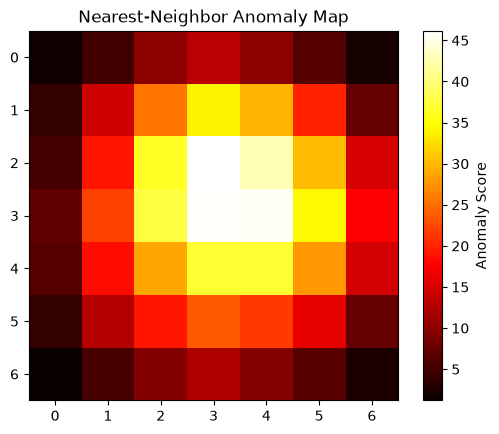

In [62]:
import matplotlib.pyplot as plt

plt.imshow(anomaly_map_nn.numpy(), cmap="hot")
plt.colorbar(label="Anomaly Score")
plt.title("Nearest-Neighbor Anomaly Map")
plt.show()

In [63]:
# ==========================================
# Nearest-Neighbor Anomaly Score Evaluation
# ==========================================

def calculate_nn_anomaly_score(dataset, normal_feature_memory):

    scores = []

    for i in range(len(dataset)):

        image, _ = dataset[i]
        image = image.unsqueeze(0)

        with torch.no_grad():
            feature_map = feature_extractor(image)

        local_features = feature_map.permute(0, 2, 3, 1)
        local_features = local_features.reshape(1, 49, 512)

        # Remove batch dimension
        local_features = local_features[0]

        # Compare every local feature with every normal feature
        distances = torch.cdist(
            local_features,
            normal_feature_memory
        )

        # Closest normal feature for each location
        nearest_distances = distances.min(dim=1).values

        # Overall image anomaly score
        score = nearest_distances.max().item()

        scores.append(score)

    return scores


# Evaluate normal test images
normal_nn_scores = calculate_nn_anomaly_score(
    normal_test_dataset,
    normal_feature_memory
)

# Evaluate defective test images
defect_nn_scores = calculate_nn_anomaly_score(
    defect_test_dataset,
    normal_feature_memory
)


# Convert to NumPy
normal_nn_scores_np = np.array(normal_nn_scores)
defect_nn_scores_np = np.array(defect_nn_scores)


print("Normal NN scores:")
print(normal_nn_scores)

print("\nDefect NN scores:")
print(defect_nn_scores)


print("\nNormal NN statistics:")
print("Minimum:", normal_nn_scores_np.min())
print("Maximum:", normal_nn_scores_np.max())
print("Mean:", normal_nn_scores_np.mean())
print("Std:", normal_nn_scores_np.std())


print("\nDefect NN statistics:")
print("Minimum:", defect_nn_scores_np.min())
print("Maximum:", defect_nn_scores_np.max())
print("Mean:", defect_nn_scores_np.mean())
print("Std:", defect_nn_scores_np.std())


print("\nDifference between means:",
      defect_nn_scores_np.mean() - normal_nn_scores_np.mean())

Normal NN scores:
[34.63340377807617, 30.95121955871582, 31.343812942504883, 31.550376892089844, 31.163959503173828, 35.63843536376953, 32.87055969238281, 33.17686080932617, 29.326114654541016, 33.124114990234375, 34.838584899902344, 34.024478912353516, 26.415124893188477, 34.67693328857422, 32.05027770996094, 25.9433536529541, 37.213253021240234, 35.0080680847168, 39.945255279541016, 33.75752258300781]

Defect NN scores:
[32.81893539428711, 39.0679931640625, 52.45929718017578, 42.18879699707031, 45.105934143066406, 46.64261245727539, 61.14558410644531, 35.78128433227539, 52.492103576660156, 34.966453552246094, 43.50104522705078, 49.46297073364258, 54.29079055786133, 35.1988639831543, 39.88346862792969, 38.74367904663086, 56.21034622192383, 59.655250549316406, 50.23516082763672, 37.88706970214844]

Normal NN statistics:
Minimum: 25.9433536529541
Maximum: 39.945255279541016
Mean: 32.882585525512695
Std: 3.2188703300756614

Defect NN statistics:
Minimum: 32.81893539428711
Maximum: 61.145

In [65]:
from sklearn.metrics import roc_auc_score

# 0 = normal, 1 = defect
y_true = [0] * len(normal_nn_scores) + [1] * len(defect_nn_scores)

y_scores = normal_nn_scores + defect_nn_scores

auc = roc_auc_score(y_true, y_scores)

print("ROC-AUC:", auc)

ROC-AUC: 0.9375


In [70]:
from pathlib import Path

defect_dir = Path("/Users/vinaykumarmandalapu/Desktop/VisionInspect_AI/mvtec_anomaly_detection/hazelnut/test/hole")

defect_image_path = sorted(defect_dir.glob("*.png"))[0]

print("Defect image:", defect_image_path)

Defect image: /Users/vinaykumarmandalapu/Desktop/VisionInspect_AI/mvtec_anomaly_detection/hazelnut/test/hole/000.png


In [71]:
category_path = defect_image_path.parent.parent.parent
defect_type = defect_image_path.parent.name

mask_path = (
    category_path
    / "ground_truth"
    / defect_type
    / f"{defect_image_path.stem}_mask.png"
)

print("Image:", defect_image_path)
print("Mask:", mask_path)
print("Exists:", mask_path.exists())

Image: /Users/vinaykumarmandalapu/Desktop/VisionInspect_AI/mvtec_anomaly_detection/hazelnut/test/hole/000.png
Mask: /Users/vinaykumarmandalapu/Desktop/VisionInspect_AI/mvtec_anomaly_detection/hazelnut/ground_truth/hole/000_mask.png
Exists: True


In [72]:
ground_truth_mask = cv2.imread(
    str(mask_path),
    cv2.IMREAD_GRAYSCALE
)

print("Mask shape:", ground_truth_mask.shape)
print("Min:", ground_truth_mask.min())
print("Max:", ground_truth_mask.max())

Mask shape: (1024, 1024)
Min: 0
Max: 255


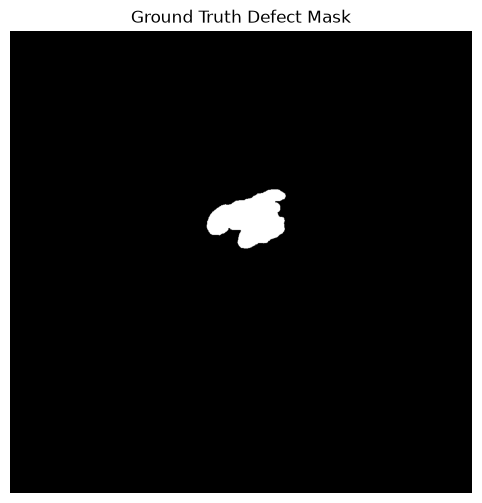

In [73]:
plt.figure(figsize=(6, 6))

plt.imshow(ground_truth_mask, cmap="gray")
plt.title("Ground Truth Defect Mask")
plt.axis("off")

plt.show()

In [74]:
# Resize the 7x7 anomaly map to the original image size
anomaly_map_resized = cv2.resize(
    anomaly_map_nn.numpy(),
    (ground_truth_mask.shape[1], ground_truth_mask.shape[0]),
    interpolation=cv2.INTER_LINEAR
)

print("Anomaly map:", anomaly_map_resized.shape)
print("Ground truth:", ground_truth_mask.shape)

Anomaly map: (1024, 1024)
Ground truth: (1024, 1024)


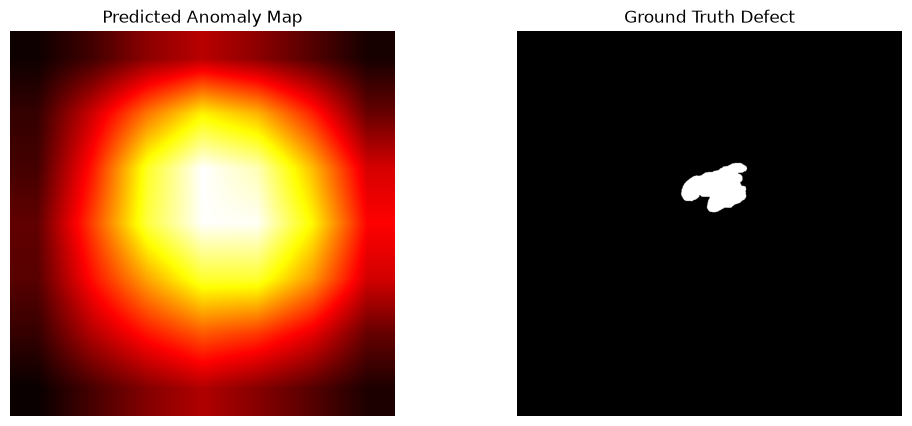

In [75]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(anomaly_map_resized, cmap="hot")
plt.title("Predicted Anomaly Map")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(ground_truth_mask, cmap="gray")
plt.title("Ground Truth Defect")
plt.axis("off")

plt.show()

In [76]:
from sklearn.metrics import roc_auc_score

# Ground truth: 0 = normal, 1 = defect
ground_truth_binary = (ground_truth_mask > 0).astype(np.uint8)

# Flatten both maps
y_true = ground_truth_binary.flatten()
y_scores = anomaly_map_resized.flatten()

pixel_auc = roc_auc_score(y_true, y_scores)

print("Pixel-level ROC-AUC:", pixel_auc)

Pixel-level ROC-AUC: 0.98905592265683


In [77]:
# Higher-resolution feature extractor
feature_extractor_high_res = torch.nn.Sequential(
    model.conv1,
    model.bn1,
    model.relu,
    model.maxpool,
    model.layer1,
    model.layer2,
    model.layer3
)

feature_extractor_high_res.eval()

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (

In [93]:
data = MVTecDataset(["/Users/vinaykumarmandalapu/Desktop/VisionInspect_AI/mvtec_anomaly_detection/hazelnut/test/hole/000.png"])
image, _ = data[0]
image = image.unsqueeze(0)
with torch.no_grad():
    high_res_feature_map = feature_extractor_high_res(image)

print(high_res_feature_map.shape)

torch.Size([1, 256, 14, 14])


In [94]:
high_res_local_features = high_res_feature_map.permute(0, 2, 3, 1)

high_res_local_features = high_res_local_features.reshape(1, 196, 256)

print(high_res_local_features.shape)

torch.Size([1, 196, 256])


In [95]:
with torch.no_grad():
    normal_high_res_feature_maps = feature_extractor_high_res(normal_images)

print(normal_high_res_feature_maps.shape)

torch.Size([20, 256, 14, 14])


In [96]:
normal_high_res_local_features = normal_high_res_feature_maps.permute(0, 2, 3, 1)

normal_high_res_local_features = normal_high_res_local_features.reshape(
    20, 196, 256
)

print(normal_high_res_local_features.shape)

torch.Size([20, 196, 256])


In [97]:
normal_high_res_memory = normal_high_res_local_features.reshape(-1, 256)

print(normal_high_res_memory.shape)

torch.Size([3920, 256])


In [98]:
with torch.no_grad():
    defect_high_res_feature_map = feature_extractor_high_res(image)

defect_high_res_local_features = defect_high_res_feature_map.permute(
    0, 2, 3, 1
)

defect_high_res_local_features = defect_high_res_local_features.reshape(
    1, 196, 256
)

print(defect_high_res_local_features.shape)

torch.Size([1, 196, 256])


In [99]:
defect_high_res_features = defect_high_res_local_features[0]

high_res_distances = torch.cdist(
    defect_high_res_features,
    normal_high_res_memory
)

print(high_res_distances.shape)

torch.Size([196, 3920])


In [100]:
high_res_nearest_distances = high_res_distances.min(dim=1).values

print(high_res_nearest_distances.shape)

torch.Size([196])


In [101]:
high_res_anomaly_map = high_res_nearest_distances.reshape(14, 14)

print(high_res_anomaly_map)

tensor([[0.2798, 0.3320, 0.3072, 0.3132, 0.3173, 0.4025, 0.4632, 0.4214, 0.5257,
         0.5630, 0.5495, 0.5672, 0.4080, 0.3269],
        [0.3128, 0.2438, 0.2102, 0.2880, 0.2504, 0.2519, 0.3428, 0.3815, 0.5567,
         0.4240, 0.3372, 0.3088, 0.3211, 0.2786],
        [0.3956, 0.3795, 0.4598, 0.6254, 0.7633, 1.0834, 1.1145, 1.4655, 1.3031,
         1.3107, 1.0206, 0.9933, 0.7154, 0.6121],
        [0.3394, 0.2922, 0.5835, 0.6804, 0.9894, 1.2983, 1.5981, 1.8569, 2.1020,
         2.3673, 1.4400, 1.1157, 0.7934, 0.6705],
        [0.4275, 0.3902, 0.7827, 0.8617, 1.3436, 1.9867, 2.5221, 2.6558, 2.4922,
         3.0568, 2.5159, 1.3309, 0.7271, 0.5345],
        [0.6075, 0.4849, 1.0909, 1.6123, 1.8163, 2.5357, 3.2329, 3.5975, 2.6072,
         2.6182, 2.5765, 1.6675, 0.7677, 0.6002],
        [0.6975, 0.6518, 1.5949, 2.0700, 1.9776, 2.4723, 3.4299, 3.6204, 2.3374,
         2.6109, 2.2036, 1.7405, 0.8385, 0.6531],
        [0.8020, 0.9586, 2.4221, 2.5090, 1.8891, 1.9394, 2.2163, 2.2374, 1.9102,
  

In [102]:
high_res_anomaly_map_resized = cv2.resize(
    high_res_anomaly_map.numpy(),
    (ground_truth_mask.shape[1], ground_truth_mask.shape[0]),
    interpolation=cv2.INTER_LINEAR
)

print(high_res_anomaly_map_resized.shape)

(1024, 1024)


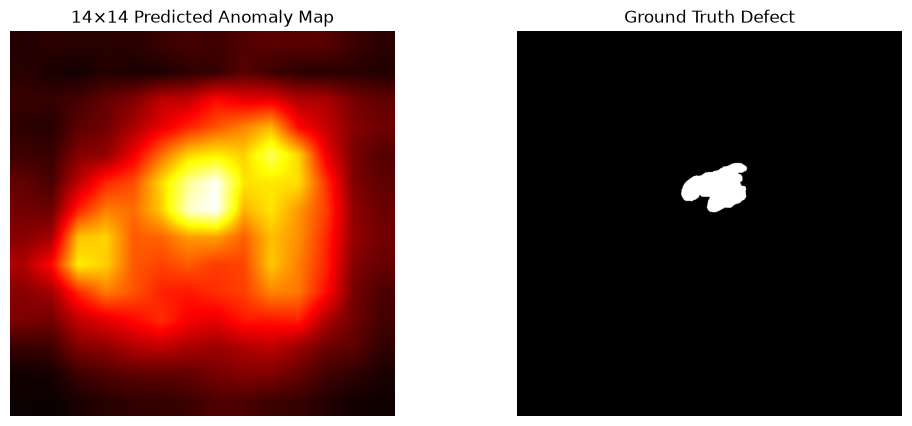

In [103]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(high_res_anomaly_map_resized, cmap="hot")
plt.title("14×14 Predicted Anomaly Map")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(ground_truth_mask, cmap="gray")
plt.title("Ground Truth Defect")
plt.axis("off")

plt.show()

In [104]:
from sklearn.metrics import roc_auc_score

ground_truth_binary = (ground_truth_mask > 0).astype(np.uint8)

high_res_pixel_auc = roc_auc_score(
    ground_truth_binary.flatten(),
    high_res_anomaly_map_resized.flatten()
)

print("14×14 Pixel-level ROC-AUC:", high_res_pixel_auc)

14×14 Pixel-level ROC-AUC: 0.9963526935790474


In [105]:
# ==========================================
# 14x14 High-Resolution Anomaly Evaluation
# ==========================================

def calculate_high_res_nn_score(dataset, normal_memory):

    scores = []

    for i in range(len(dataset)):

        image, _ = dataset[i]
        image = image.unsqueeze(0)

        with torch.no_grad():
            feature_map = feature_extractor_high_res(image)

        # [1, 256, 14, 14]
        local_features = feature_map.permute(0, 2, 3, 1)

        # [1, 196, 256]
        local_features = local_features.reshape(1, 196, 256)

        # Remove batch dimension
        local_features = local_features[0]

        # [196, 3920]
        distances = torch.cdist(
            local_features,
            normal_memory
        )

        # Closest normal feature for every location
        nearest_distances = distances.min(dim=1).values

        # One score for the entire image
        score = nearest_distances.max().item()

        scores.append(score)

    return scores


# Evaluate normal test images
normal_high_res_scores = calculate_high_res_nn_score(
    normal_test_dataset,
    normal_high_res_memory
)

# Evaluate defective test images
defect_high_res_scores = calculate_high_res_nn_score(
    defect_test_dataset,
    normal_high_res_memory
)


# Convert to NumPy
normal_high_res_np = np.array(normal_high_res_scores)
defect_high_res_np = np.array(defect_high_res_scores)


# Print scores
print("Normal high-resolution scores:")
print(normal_high_res_scores)

print("\nDefect high-resolution scores:")
print(defect_high_res_scores)


# Statistics
print("\nNormal high-resolution statistics:")
print("Minimum:", normal_high_res_np.min())
print("Maximum:", normal_high_res_np.max())
print("Mean:", normal_high_res_np.mean())
print("Std:", normal_high_res_np.std())


print("\nDefect high-resolution statistics:")
print("Minimum:", defect_high_res_np.min())
print("Maximum:", defect_high_res_np.max())
print("Mean:", defect_high_res_np.mean())
print("Std:", defect_high_res_np.std())


# Image-level ROC-AUC
y_true = (
    [0] * len(normal_high_res_scores)
    + [1] * len(defect_high_res_scores)
)

y_scores = normal_high_res_scores + defect_high_res_scores

image_auc_high_res = roc_auc_score(
    y_true,
    y_scores
)

print("\n14x14 Image-level ROC-AUC:", image_auc_high_res)

Normal high-resolution scores:
[2.3243248462677, 2.7097067832946777, 2.2877681255340576, 3.037785768508911, 2.6128265857696533, 3.1782331466674805, 3.546630382537842, 2.6901891231536865, 2.7079341411590576, 2.2645604610443115, 3.4486491680145264, 3.373293876647949, 2.213252544403076, 2.6396820545196533, 3.5259971618652344, 2.3816754817962646, 3.49186635017395, 2.399662733078003, 2.617685079574585, 2.391065835952759]

Defect high-resolution scores:
[2.9241786003112793, 2.5253875255584717, 3.876286268234253, 3.2273051738739014, 3.7341649532318115, 3.8201065063476562, 4.141244888305664, 3.433347702026367, 3.3611013889312744, 3.5468082427978516, 3.2880258560180664, 3.196279525756836, 2.9946680068969727, 3.064014434814453, 2.9877994060516357, 3.287220001220703, 3.166908025741577, 3.4739394187927246, 3.9180707931518555, 3.280776262283325]

Normal high-resolution statistics:
Minimum: 2.213252544403076
Maximum: 3.546630382537842
Mean: 2.792139482498169
Std: 0.461289327586567

Defect high-resol

In [106]:
# ==========================================
# 14x14 Pixel-Level Localization Evaluation
# ==========================================

pixel_auc_scores = []

for i in range(len(defect_test_dataset)):

    # Get defective image
    image, image_path = defect_test_dataset[i]
    image = image.unsqueeze(0)

    # -----------------------------
    # Extract 14x14 local features
    # -----------------------------
    with torch.no_grad():
        feature_map = feature_extractor_high_res(image)

    local_features = feature_map.permute(0, 2, 3, 1)
    local_features = local_features.reshape(1, 196, 256)
    local_features = local_features[0]

    # -----------------------------
    # Compare with normal memory
    # -----------------------------
    distances = torch.cdist(
        local_features,
        normal_high_res_memory
    )

    nearest_distances = distances.min(dim=1).values

    # -----------------------------
    # Create 14x14 anomaly map
    # -----------------------------
    anomaly_map = nearest_distances.reshape(14, 14)

    # -----------------------------
    # Resize to original image size
    # -----------------------------
    anomaly_map_resized = cv2.resize(
        anomaly_map.numpy(),
        (1024, 1024),
        interpolation=cv2.INTER_LINEAR
    )

    # -----------------------------
    # Find corresponding mask
    # -----------------------------
    image_path = Path(image_path)

    category_path = image_path.parent.parent.parent
    defect_type = image_path.parent.name

    mask_path = (
        category_path
        / "ground_truth"
        / defect_type
        / f"{image_path.stem}_mask.png"
    )

    # Load ground-truth mask
    ground_truth_mask = cv2.imread(
        str(mask_path),
        cv2.IMREAD_GRAYSCALE
    )

    # -----------------------------
    # Pixel-level ROC-AUC
    # -----------------------------
    ground_truth_binary = (
        ground_truth_mask > 0
    ).astype(np.uint8)

    pixel_auc = roc_auc_score(
        ground_truth_binary.flatten(),
        anomaly_map_resized.flatten()
    )

    pixel_auc_scores.append(pixel_auc)

    print(
        f"{i + 1:02d} | "
        f"{image_path.name} | "
        f"Pixel AUC: {pixel_auc:.4f}"
    )


# ==========================================
# Final statistics
# ==========================================

pixel_auc_np = np.array(pixel_auc_scores)

print("\n==========================================")
print("14x14 Pixel-Level Localization Results")
print("==========================================")

print("Minimum:", pixel_auc_np.min())
print("Maximum:", pixel_auc_np.max())
print("Mean:", pixel_auc_np.mean())
print("Median:", np.median(pixel_auc_np))
print("Std:", pixel_auc_np.std())

01 | 002.png | Pixel AUC: 0.9091
02 | 016.png | Pixel AUC: 0.9101
03 | 017.png | Pixel AUC: 0.9706
04 | 003.png | Pixel AUC: 0.9613
05 | 015.png | Pixel AUC: 0.9690
06 | 001.png | Pixel AUC: 0.9775
07 | 000.png | Pixel AUC: 0.9885
08 | 014.png | Pixel AUC: 0.9980
09 | 010.png | Pixel AUC: 0.9810
10 | 004.png | Pixel AUC: 0.9953
11 | 005.png | Pixel AUC: 0.9651
12 | 011.png | Pixel AUC: 0.9744
13 | 007.png | Pixel AUC: 0.9501
14 | 013.png | Pixel AUC: 0.9691
15 | 012.png | Pixel AUC: 0.9465
16 | 006.png | Pixel AUC: 0.9781
17 | 008.png | Pixel AUC: 0.9903
18 | 009.png | Pixel AUC: 0.9804
19 | 002.png | Pixel AUC: 0.9872
20 | 016.png | Pixel AUC: 0.9962

14x14 Pixel-Level Localization Results
Minimum: 0.9090867604758917
Maximum: 0.9980259227623889
Mean: 0.9698964463795612
Median: 0.9759838298386208
Std: 0.0243687009734993
